# Problema 2 – Regresión: Estimación de Edad a partir de Imágenes Faciales

**Universidad EAFIT – Introducción a la Inteligencia Artificial (2026-01)**

**Dataset:** Faces: Age Detection from Images  
**Fuente:** Kaggle – [arashnic/faces-age-detection-dataset](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset)

---

## 0. Importaciones y configuración global

In [35]:
import os
import re
import csv
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import r2_score
from itertools import chain
# ─── Configuración ────────────────────────────────────────────────────────────

DATA_DIR_1 = Path("/kaggle/input/datasets/arashnic/faces-age-detection-dataset/faces/Train")
DATA_DIR_2 = Path("/kaggle/input/datasets/arashnic/faces-age-detection-dataset/faces_02/part3")     # carpeta con todas las imágenes originales
DATASET_DIR  = Path("dataset")    # salida del split: train/ val/ test/
IMG_SIZE     = 96                 # resolución de entrada al modelo
BATCH_SIZE   = 32
NUM_EPOCHS   = 30
LR           = 1e-3
NUM_WORKERS  = 2

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Dispositivo: cuda
PyTorch version: 2.10.0+cu128


---
## 1. Análisis Preliminar del Problema

### 1a. Justificación: ¿Por qué es un problema de Regresión?

Este es un problema de **regresión** porque la variable objetivo (edad) es **continua y numérica**, no una categoría discreta. La edad puede tomar cualquier valor entero dentro de un rango (e.g., 0–116 años), y existe una relación de orden natural entre los valores (25 años es menos que 30 años).

**Variable objetivo (target):** `edad` → número entero extraído del nombre de archivo, que se trata como valor flotante para la regresión. Ejemplo: `25_0_2_20170116.jpg` → edad = 25.

Si se usara clasificación (discretizar en rangos), se perdería información ordinal valiosa y el modelo no podría cuantificar en cuántos años se equivoca. La regresión permite métricas interpretables como MAE ("el modelo se equivoca X años en promedio").

### 1b. Características de entrada (imágenes)

- **Tipo:** Imágenes faciales en formato JPEG/PNG
- **Espacio de color:** RGB (3 canales)
- **Dimensiones originales:** Variables (se normalizan a 96×96 px antes del entrenamiento)
- **Contenido:** Rostros humanos centrados, con variedad de géneros, razas e iluminaciones
- **Nombre de archivo:** `[age]_[gender]_[race]_[datetime].jpg`
  - `gender`: 0=Masculino, 1=Femenino
  - `race`: 0=White, 1=Black, 2=Asian, 3=Indian, 4=Other

### 1c. Protocolo de adquisición de datos

El dataset proviene del proyecto **UTKFace** (University of Tennessee, Knoxville). Las imágenes fueron recolectadas con las siguientes características:
- Imágenes "in the wild" (condiciones no controladas)
- Anotaciones de edad, género y etnia realizadas manualmente con verificación cruzada
- El rango de edades cubre 0–116 años
- ~20,000 imágenes en total
- Ampliamente usado como benchmark en tareas de estimación de edad facial

In [36]:
EXTENSIONS = {".jpg", ".jpeg", ".png"}

def parse_age(filename):
    match = re.match(r'^(\d+)_', filename)
    if match:
        age = int(match.group(1))
        if 0 <= age <= 116:
            return age
    return None

# Recolectar imágenes de AMBAS carpetas
all_files = []
for p in chain(DATA_DIR_1.iterdir(), DATA_DIR_2.iterdir()):
    if p.is_file() and p.suffix.lower() in EXTENSIONS:
        age = parse_age(p.name)
        if age is not None:
            all_files.append({"path": str(p), "filename": p.name, "age": age})

df_meta = pd.DataFrame(all_files)
print(f"Total imágenes válidas: {len(df_meta):,}")
print(df_meta.head())

Total imágenes válidas: 3,250
                                                path  \
0  /kaggle/input/datasets/arashnic/faces-age-dete...   
1  /kaggle/input/datasets/arashnic/faces-age-dete...   
2  /kaggle/input/datasets/arashnic/faces-age-dete...   
3  /kaggle/input/datasets/arashnic/faces-age-dete...   
4  /kaggle/input/datasets/arashnic/faces-age-dete...   

                       filename  age  
0  42_0_0_20170116224637121.jpg   42  
1  26_0_3_20170119175419890.jpg   26  
2  28_0_3_20170119194930475.jpg   28  
3  55_0_0_20170120140655585.jpg   55  
4  22_1_3_20170119155949578.jpg   22  


---
## 2. Análisis Exploratorio de Datos (EDA)

In [37]:
# ── Estadísticos descriptivos de la edad ──────────────────────────────────────
print("=== Estadísticos descriptivos – variable 'edad' ===")
print(df_meta["age"].describe())
print(f"\nModa    : {df_meta['age'].mode()[0]} años")
print(f"Mediana : {df_meta['age'].median():.0f} años")
print(f"Media   : {df_meta['age'].mean():.1f} años")
print(f"Desv.std: {df_meta['age'].std():.1f} años")

=== Estadísticos descriptivos – variable 'edad' ===
count    3250.000000
mean       40.550769
std        17.309044
min         1.000000
25%        26.000000
50%        35.000000
75%        53.000000
max       116.000000
Name: age, dtype: float64

Moda    : 26 años
Mediana : 35 años
Media   : 40.6 años
Desv.std: 17.3 años


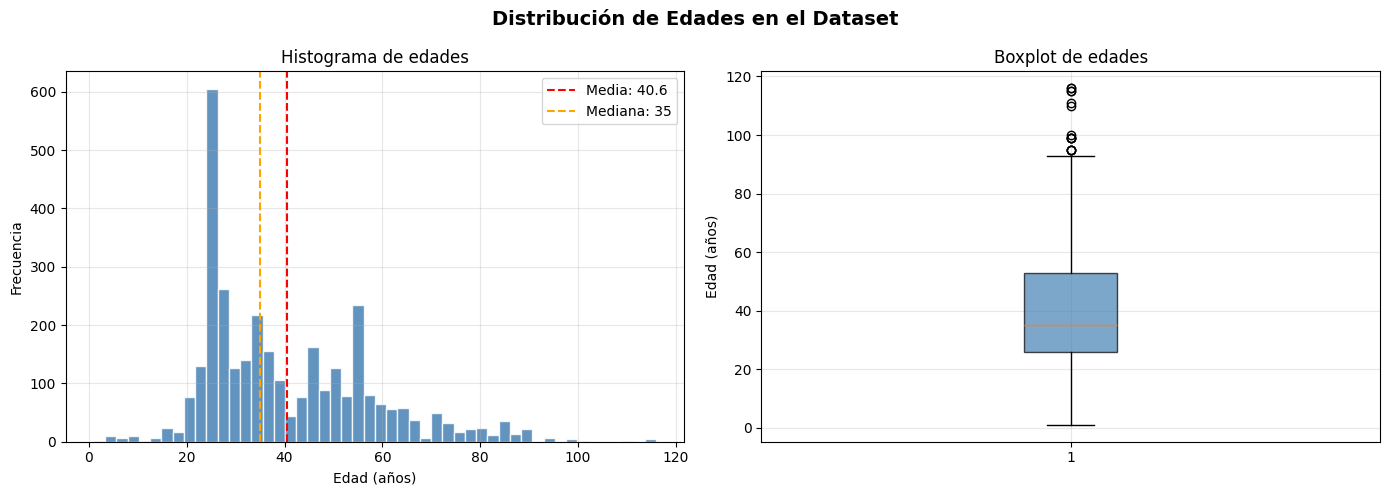

In [38]:
# ── Distribución de edades ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de Edades en el Dataset", fontsize=14, fontweight='bold')

# Histograma
axes[0].hist(df_meta["age"], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df_meta["age"].mean(), color='red', linestyle='--', label=f'Media: {df_meta["age"].mean():.1f}')
axes[0].axvline(df_meta["age"].median(), color='orange', linestyle='--', label=f'Mediana: {df_meta["age"].median():.0f}')
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma de edades")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df_meta["age"], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_ylabel("Edad (años)")
axes[1].set_title("Boxplot de edades")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación – Distribución de edades:**

- La distribución está **sesgada hacia edades jóvenes** (20–40 años), lo que refleja un sesgo de recolección: en internet abundan más imágenes de adultos jóvenes.
- Las colas son largas: hay pocas imágenes de niños muy pequeños (0–5 años) y de personas mayores (>70 años).
- Este **desbalance es un desafío para el modelo**: aprenderá mejor a predecir edades en rangos donde hay más ejemplos, y tendrá mayor error en edades extremas.
- La mediana (~30 años) es menor que la media, confirmando el sesgo positivo.

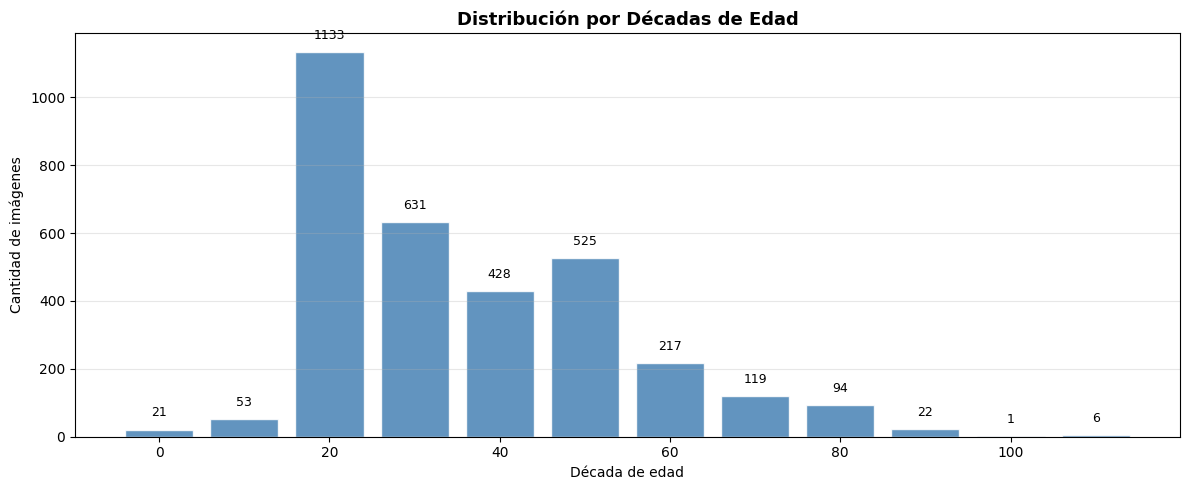

Distribución por décadas:
    0–  9 años:    21 imágenes (0.6%)
   10– 19 años:    53 imágenes (1.6%)
   20– 29 años: 1,133 imágenes (34.9%)
   30– 39 años:   631 imágenes (19.4%)
   40– 49 años:   428 imágenes (13.2%)
   50– 59 años:   525 imágenes (16.2%)
   60– 69 años:   217 imágenes (6.7%)
   70– 79 años:   119 imágenes (3.7%)
   80– 89 años:    94 imágenes (2.9%)
   90– 99 años:    22 imágenes (0.7%)
  100–109 años:     1 imágenes (0.0%)
  110–119 años:     6 imágenes (0.2%)


In [39]:
# ── Análisis de balance por décadas ───────────────────────────────────────────
df_meta["decade"] = (df_meta["age"] // 10) * 10
decade_counts = df_meta["decade"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(decade_counts.index, decade_counts.values, width=8,
              color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel("Década de edad")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución por Décadas de Edad", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, decade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Distribución por décadas:")
for decade, count in decade_counts.items():
    pct = count / len(df_meta) * 100
    print(f"  {decade:3d}–{decade+9:3d} años: {count:>5,} imágenes ({pct:.1f}%)")

**Interpretación – Balance por décadas:**

- Las décadas 20–29 y 30–39 concentran la mayoría de los ejemplos.
- Los extremos (0–9 años y >70 años) tienen muy pocas imágenes, lo que puede generar **underfitting** en esos rangos.
- Este sesgo podría motivar técnicas como **sobremuestreo** de clases poco representadas o el uso de una función de pérdida ponderada.

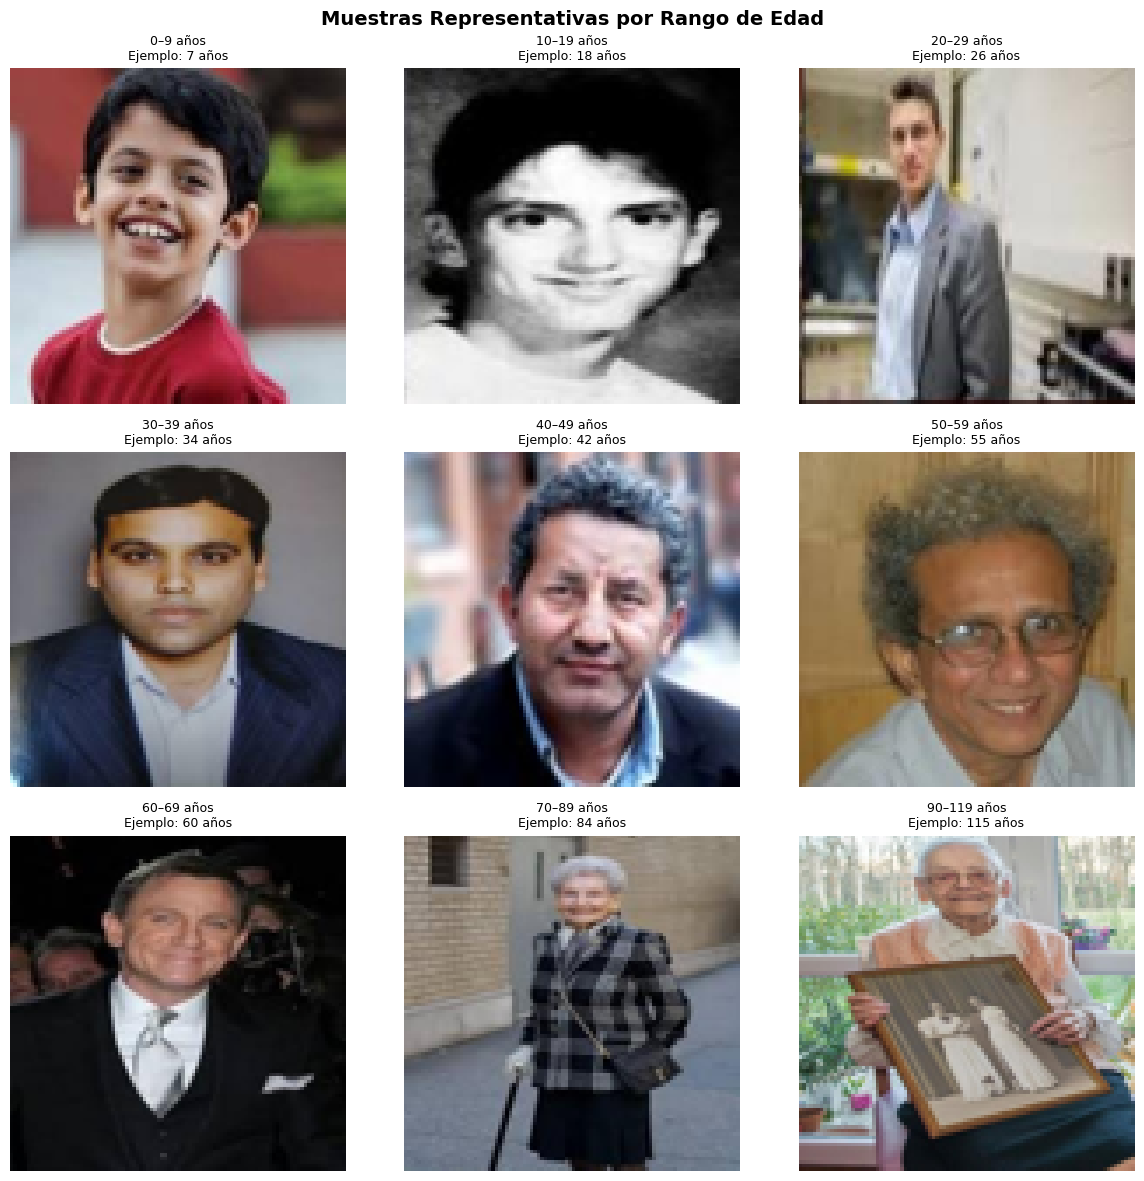

In [40]:
# ── Visualización de muestras representativas ─────────────────────────────────
age_ranges = [(0,10), (10,20), (20,30), (30,40), (40,50),
              (50,60), (60,70), (70,90), (90,120)]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Muestras Representativas por Rango de Edad", fontsize=14, fontweight='bold')

for ax, (a_min, a_max) in zip(axes.flat, age_ranges):
    subset = df_meta[(df_meta["age"] >= a_min) & (df_meta["age"] < a_max)]
    if len(subset) > 0:
        row = subset.sample(1, random_state=SEED).iloc[0]
        try:
            img = Image.open(row["path"]).convert("RGB").resize((96, 96))
            ax.imshow(img)
            ax.set_title(f"{a_min}–{a_max-1} años\nEjemplo: {row['age']} años",
                         fontsize=9)
        except Exception:
            ax.set_title(f"{a_min}–{a_max-1} años\n(error al cargar)", fontsize=9)
    else:
        ax.set_title(f"{a_min}–{a_max-1} años\n(sin muestras)", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Interpretación – Muestras por rango:**

- Las imágenes muestran condiciones variadas: iluminación, pose, expresión facial, fondo.
- Se puede observar que las imágenes de niños y personas muy mayores son menos comunes.
- La variabilidad visual es alta (imágenes "in the wild"), lo que hace que la tarea sea desafiante.

Analizando dimensiones de una muestra de imágenes...

Ancho  – media: 400px  |  min: 128  |  max: 2050
Alto   – media: 410px  |  min: 173  |  max: 1019


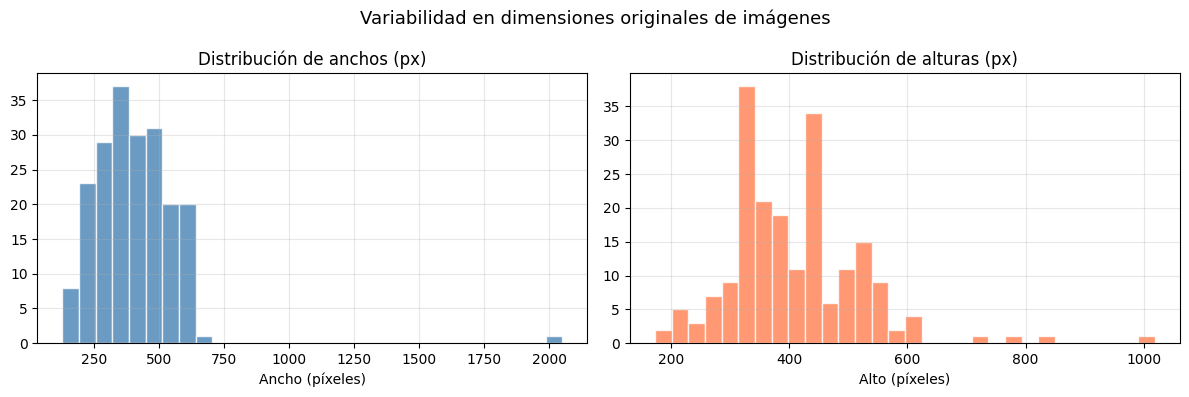

In [41]:
# ── Análisis de dimensiones de imágenes ────────────────────────────────────────
print("Analizando dimensiones de una muestra de imágenes...")
sample_files = df_meta.sample(min(200, len(df_meta)), random_state=SEED)
widths, heights = [], []

for _, row in sample_files.iterrows():
    try:
        with Image.open(row["path"]) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

widths  = np.array(widths)
heights = np.array(heights)

print(f"\nAncho  – media: {widths.mean():.0f}px  |  min: {widths.min()}  |  max: {widths.max()}")
print(f"Alto   – media: {heights.mean():.0f}px  |  min: {heights.min()}  |  max: {heights.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title("Distribución de anchos (px)")
axes[0].set_xlabel("Ancho (píxeles)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(heights, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title("Distribución de alturas (px)")
axes[1].set_xlabel("Alto (píxeles)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Variabilidad en dimensiones originales de imágenes", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación – Dimensiones:**

- Las imágenes tienen **dimensiones variables**, lo que confirma la necesidad de un redimensionamiento uniforme antes del entrenamiento.
- La mayoría de las imágenes son cuadradas o casi cuadradas, centradas en el rostro.
- Usaremos `transforms.Resize((96, 96))` para homogeneizar a 96×96 px, que ofrece más detalle que 64×64 manteniendo un costo computacional razonable.

---
## 3. Procesamiento de Datos

### 3a. División del dataset: 70% train / 15% val / 15% test

**Justificación de proporciones:**
- 70% train: suficiente volumen para que la CNN aprenda representaciones visuales complejas.
- 15% val: permite monitorear overfitting y ajustar hiperparámetros sin tocar el test.
- 15% test: evaluación final sin sesgo de desarrollo.

In [42]:
# ── División 70/15/15 ──────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
COPY_FILES  = True  # True = copia (conserva original), False = mueve (más rápido)

all_images = [p for p in chain(DATA_DIR_1.iterdir(), DATA_DIR_2.iterdir())
              if p.is_file() and p.suffix.lower() in {".jpg",".jpeg",".png"}
              and parse_age(p.name) is not None]

random.seed(SEED)
random.shuffle(all_images)

total   = len(all_images)
n_train = int(total * TRAIN_RATIO)
n_val   = int(total * VAL_RATIO)

splits = {
    "train": all_images[:n_train],
    "val"  : all_images[n_train:n_train + n_val],
    "test" : all_images[n_train + n_val:],
}

print("División calculada:")
for name, files in splits.items():
    print(f"  {name:6s}: {len(files):>6,} imágenes ({len(files)/total*100:.1f}%)")

# Crear carpetas destino
for split_name in splits:
    (DATASET_DIR / split_name).mkdir(parents=True, exist_ok=True)

# Copiar/mover archivos
fn = shutil.copy2 if COPY_FILES else shutil.move
for split_name, file_list in splits.items():
    print(f"Procesando {split_name}...", end=" ", flush=True)
    dest = DATASET_DIR / split_name
    for src in file_list:
        dst = dest / src.name
        if not dst.exists():
            fn(src, dst)
    print("✓")

# Verificación
print("\nVerificación final:")
for split_name in splits:
    count = sum(1 for f in (DATASET_DIR/split_name).iterdir()
                if f.suffix.lower() in {".jpg",".jpeg",".png"})
    print(f"  {split_name}: {count:,} imágenes")

División calculada:
  train :  2,275 imágenes (70.0%)
  val   :    487 imágenes (15.0%)
  test  :    488 imágenes (15.0%)
Procesando train... ✓
Procesando val... ✓
Procesando test... ✓

Verificación final:
  train: 2,275 imágenes
  val: 487 imágenes
  test: 488 imágenes


### 3b. Pipeline de transformaciones (preprocesamiento)

In [43]:
# Valores ImageNet estándar para normalización
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Pipeline de ENTRENAMIENTO (con data augmentation) ─────────────────────────
# Justificación de augmentation:
# - RandomHorizontalFlip: la edad no depende de la orientación del rostro
# - ColorJitter: variaciones de iluminación y contraste son comunes en imágenes reales
# - RandomRotation(±10°): simula ligeras inclinaciones de cabeza
# - RandomAffine: simula pequeñas traslaciones (rostro no siempre centrado)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Pipeline de VALIDACIÓN y TEST (sin augmentation) ──────────────────────────
# En evaluación queremos resultados deterministas y comparables
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Pipeline de preprocesamiento definido ✓")
print(f"  Train  : Resize({IMG_SIZE}) → HFlip → ColorJitter → Rotation → Affine → ToTensor → Normalize")
print(f"  Val/Test: Resize({IMG_SIZE}) → ToTensor → Normalize")

Pipeline de preprocesamiento definido ✓
  Train  : Resize(96) → HFlip → ColorJitter → Rotation → Affine → ToTensor → Normalize
  Val/Test: Resize(96) → ToTensor → Normalize


### 3c. Dataset personalizado con PyTorch

In [44]:
class AgeDataset(Dataset):
    """
    Dataset de imágenes faciales con etiqueta de edad.
    Nombre de archivo esperado: [age]_[gender]_[race]_[datetime].jpg
    """
    def __init__(self, root_dir: Path, transform=None):
        self.transform = transform
        EXTENSIONS = {".jpg", ".jpeg", ".png"}
        self.samples = []

        for img_path in Path(root_dir).iterdir():
            if img_path.suffix.lower() not in EXTENSIONS:
                continue
            age = self._parse_age(img_path.name)
            if age is not None:
                self.samples.append((img_path, float(age)))

        print(f"  [{Path(root_dir).name}] {len(self.samples):,} imágenes")

    @staticmethod
    def _parse_age(filename):
        match = re.match(r'^(\d+)_', filename)
        if match:
            age = int(match.group(1))
            if 0 <= age <= 116:
                return age
        return None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)


# Crear datasets
print("Construyendo datasets...")
train_dataset = AgeDataset(DATASET_DIR / "train", transform=train_transform)
val_dataset   = AgeDataset(DATASET_DIR / "val",   transform=val_transform)
test_dataset  = AgeDataset(DATASET_DIR / "test",  transform=val_transform)

print(f"\nTotal: {len(train_dataset)+len(val_dataset)+len(test_dataset):,} imágenes")

Construyendo datasets...
  [train] 2,275 imágenes
  [val] 487 imágenes
  [test] 488 imágenes

Total: 3,250 imágenes


In [45]:
# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"), drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda")
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda")
)

print("DataLoaders creados ✓")
print(f"  Train → {len(train_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Val   → {len(val_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Test  → {len(test_loader)} batches × {BATCH_SIZE} imgs")

DataLoaders creados ✓
  Train → 71 batches × 32 imgs
  Val   → 16 batches × 32 imgs
  Test  → 16 batches × 32 imgs


---
## 4. Entrenamiento del Modelo CNN para Regresión

### 4a. Arquitectura: CNN mejorada con BatchNorm, Dropout y más capacidad

**Justificación de diseño:**
- **5 bloques convolucionales** (vs. 3 del baseline): permite extraer características más abstractas (piel, arrugas, estructura ósea)
- **BatchNorm2d**: estabiliza el entrenamiento normalizando las activaciones de cada capa
- **Dropout(0.4)**: regularización para evitar overfitting con ~20k imágenes
- **Función de activación de salida**: ninguna (linear) → apropiada para regresión en valores continuos
- **Función de pérdida**: MSELoss (sensible a outliers, genera gradientes grandes que aceleran el aprendizaje)
- **IMG_SIZE=96**: más detalle facial que 64×64 con costo aceptable

In [46]:
class AgeCNN(nn.Module):
    """
    CNN para regresión de edad facial.
    
    Arquitectura:
      Entrada: [B, 3, 96, 96]
      Bloque 1: Conv(3→32)  + BN + ReLU + MaxPool  → [B, 32, 48, 48]
      Bloque 2: Conv(32→64) + BN + ReLU + MaxPool  → [B, 64, 24, 24]
      Bloque 3: Conv(64→128)+ BN + ReLU + MaxPool  → [B, 128, 12, 12]
      Bloque 4: Conv(128→256)+BN + ReLU + MaxPool  → [B, 256, 6, 6]
      Bloque 5: Conv(256→256)+BN + ReLU + MaxPool  → [B, 256, 3, 3]
      Flatten                                       → [B, 256*3*3 = 2304]
      FC(2304→512) + BN1d + ReLU + Dropout(0.4)    → [B, 512]
      FC(512→128)  + ReLU + Dropout(0.3)            → [B, 128]
      FC(128→1)                                     → [B, 1]  ← edad predicha
    """

    def __init__(self, dropout_rate: float = 0.4):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),  # normaliza activaciones → entrenamiento estable
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3,    32),   # 96→48
            conv_block(32,   64),   # 48→24
            conv_block(64,  128),   # 24→12
            conv_block(128, 256),   # 12→6
            conv_block(256, 256),   #  6→3
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.75),
            nn.Linear(128, 1),  # salida lineal → sin activación, apropiado para regresión
        )

        # Inicialización de pesos (He init para ReLU)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x


model = AgeCNN(dropout_rate=0.4).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")

# Verificar forward pass
with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out = model(dummy)
    print(f"Input:  {dummy.shape}")
    print(f"Output: {out.shape}  ← [batch_size, 1]")

Parámetros entrenables: 2,226,209
Input:  torch.Size([4, 3, 96, 96])
Output: torch.Size([4, 1])  ← [batch_size, 1]


### 4b. Función de pérdida, optimizador y scheduler

In [47]:
# Función de pérdida: MSELoss
# Justificación: penaliza errores grandes cuadráticamente, incentivando al modelo
# a evitar predicciones muy alejadas del valor real.
criterion = nn.MSELoss()

# Optimizador: Adam con weight decay (L2 regularización adicional)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Scheduler: Cosine Annealing → reduce LR suavemente hasta lr_min
# Beneficio: evita oscilaciones al final del entrenamiento
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5
)

def compute_mae(preds, targets):
    """MAE en años – más interpretable que MSE."""
    return torch.abs(preds - targets).mean().item()

print(f"Loss     : MSELoss")
print(f"Métrica  : MAE (años), RMSE, R²")
print(f"Optimizer: Adam  lr={LR}  weight_decay=1e-4")
print(f"Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")

Loss     : MSELoss
Métrica  : MAE (años), RMSE, R²
Optimizer: Adam  lr=0.001  weight_decay=1e-4
Scheduler: CosineAnnealingLR (T_max=30)


### 4c. Loop de entrenamiento

In [48]:
history = {"train_loss": [], "val_loss": [],
           "train_mae" : [], "val_mae" : [],
           "lr"        : []}

best_val_mae    = float("inf")
best_model_path = "best_age_cnn.pth"
patience_count  = 0
EARLY_STOP      = 8  # épocas sin mejora antes de detener

print(f"{'Época':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'LR':>8}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):

    # ─── FASE ENTRENAMIENTO ───────────────────────────────────────────────────
    model.train()
    train_loss_sum = train_mae_sum = 0.0

    for batch_imgs, batch_ages in train_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        batch_ages = batch_ages.to(DEVICE)

        optimizer.zero_grad()
        preds = model(batch_imgs).squeeze(1)
        loss  = criterion(preds, batch_ages)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradiente clipping
        optimizer.step()

        train_loss_sum += loss.item()
        train_mae_sum  += compute_mae(preds.detach(), batch_ages)

    train_loss = train_loss_sum / len(train_loader)
    train_mae  = train_mae_sum  / len(train_loader)

    # ─── FASE VALIDACIÓN ─────────────────────────────────────────────────────
    model.eval()
    val_loss_sum = val_mae_sum = 0.0

    with torch.no_grad():
        for batch_imgs, batch_ages in val_loader:
            batch_imgs = batch_imgs.to(DEVICE)
            batch_ages = batch_ages.to(DEVICE)
            preds = model(batch_imgs).squeeze(1)
            val_loss_sum += criterion(preds, batch_ages).item()
            val_mae_sum  += compute_mae(preds, batch_ages)

    val_loss = val_loss_sum / len(val_loader)
    val_mae  = val_mae_sum  / len(val_loader)
    current_lr = optimizer.param_groups[0]['lr']

    scheduler.step()

    # Guardar mejor modelo
    if val_mae < best_val_mae:
        best_val_mae  = val_mae
        patience_count = 0
        torch.save(model.state_dict(), best_model_path)
        best_marker = " ← mejor"
    else:
        patience_count += 1
        best_marker = ""

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["lr"].append(current_lr)

    print(f"{epoch:>5} | {train_loss:>10.2f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.2f} | {val_mae:>7.2f} | {current_lr:>8.6f}{best_marker}")

    # Early stopping
    if patience_count >= EARLY_STOP:
        print(f"\nEarly stopping en época {epoch} (sin mejora en {EARLY_STOP} épocas)")
        break

print(f"\nMejor Val MAE: {best_val_mae:.2f} años")

Época | Train Loss | Train MAE | Val Loss | Val MAE |       LR
-----------------------------------------------------------------
    1 |     507.47 |     17.14 |   272.71 |   12.82 | 0.001000 ← mejor
    2 |     273.63 |     12.90 |   269.38 |   12.58 | 0.000997 ← mejor
    3 |     257.95 |     12.42 |   224.86 |   11.35 | 0.000989 ← mejor
    4 |     248.53 |     12.05 |   253.60 |   11.64 | 0.000976
    5 |     246.53 |     12.11 |   271.10 |   12.09 | 0.000957
    6 |     225.13 |     11.40 |   205.33 |   11.12 | 0.000934 ← mejor
    7 |     212.19 |     11.08 |   236.80 |   11.30 | 0.000905
    8 |     213.21 |     11.14 |   242.31 |   11.57 | 0.000873
    9 |     216.20 |     11.20 |   241.13 |   11.52 | 0.000836
   10 |     197.89 |     10.80 |   200.48 |   10.53 | 0.000796 ← mejor
   11 |     191.59 |     10.65 |   180.73 |   10.43 | 0.000753 ← mejor
   12 |     194.80 |     10.60 |   199.96 |   10.81 | 0.000706
   13 |     192.18 |     10.45 |   182.33 |   10.46 | 0.000658
   1

### 4d. Curvas de aprendizaje – Diagnóstico de overfitting/underfitting

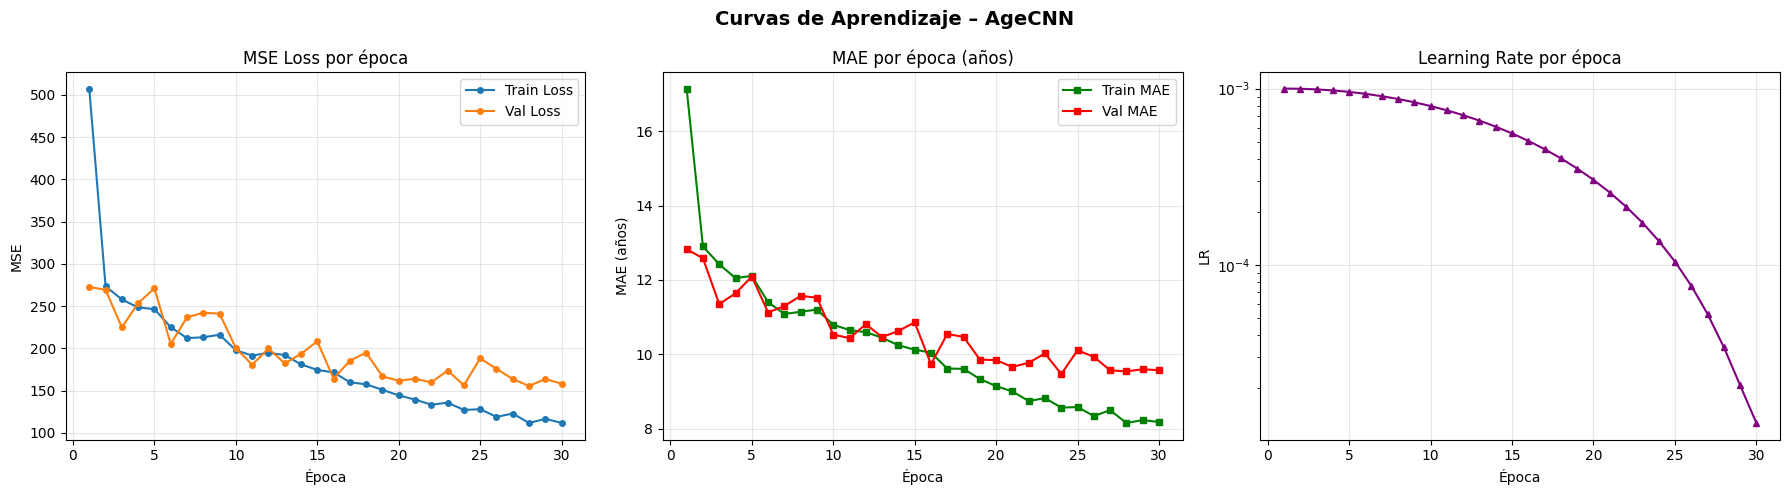


=== Diagnóstico Final ===
  Train MAE última época: 8.18 años
  Val MAE   última época: 9.57 años
  Gap (val - train MAE) : 1.39 años
  → Balance razonable entre bias y varianza ✓


In [49]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Curvas de Aprendizaje – AgeCNN", fontsize=14, fontweight='bold')

# MSE Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o", markersize=4)
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o", markersize=4)
axes[0].set_title("MSE Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(epochs_range, history["train_mae"], label="Train MAE", marker="s", markersize=4, color="green")
axes[1].plot(epochs_range, history["val_mae"],   label="Val MAE",   marker="s", markersize=4, color="red")
axes[1].set_title("MAE por época (años)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MAE (años)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(epochs_range, history["lr"], marker="^", markersize=4, color="purple")
axes[2].set_title("Learning Rate por época")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("LR")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnóstico
gap = history["val_mae"][-1] - history["train_mae"][-1]
print(f"\n=== Diagnóstico Final ===")
print(f"  Train MAE última época: {history['train_mae'][-1]:.2f} años")
print(f"  Val MAE   última época: {history['val_mae'][-1]:.2f} años")
print(f"  Gap (val - train MAE) : {gap:.2f} años")
if gap > 3:
    print("  → OVERFITTING detectado: el modelo memoriza entrenamiento pero no generaliza")
    print("    Solución: más Dropout, más augmentation, menos capacidad, más datos")
elif history['train_mae'][-1] > 9:
    print("  → UNDERFITTING: el modelo tiene poca capacidad o pocas épocas")
    print("    Solución: más capas, más filtros, más épocas, LR más alto")
else:
    print("  → Balance razonable entre bias y varianza ✓")

---
## 5. Evaluación Final en Test Set

> El test set se usa **una sola vez**, al final, para reportar el desempeño real del modelo.

In [50]:
# Cargar mejor modelo guardado
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds   = []
all_targets = []

with torch.no_grad():
    for batch_imgs, batch_ages in test_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        preds = model(batch_imgs).squeeze(1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(batch_ages.tolist())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

# ── Cálculo de métricas ───────────────────────────────────────────────────────
test_mae  = np.abs(all_preds - all_targets).mean()
test_rmse = np.sqrt(((all_preds - all_targets) ** 2).mean())
test_r2   = r2_score(all_targets, all_preds)

print("=" * 45)
print("  RESULTADOS FINALES – Test Set")
print("=" * 45)
print(f"  MAE  : {test_mae:.2f} años")
print(f"  RMSE : {test_rmse:.2f} años")
print(f"  R²   : {test_r2:.4f}")
print("=" * 45)

# Tabla resumen por split
print("\nTabla comparativa de métricas:")
print(f"{'Split':>8} | {'MAE (años)':>10} | {'RMSE (años)':>11} | {'R²':>6}")
print("-" * 45)

# Calcular también para train y val
def evaluate_loader(loader, model, device):
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for imgs, ages in loader:
            imgs = imgs.to(device)
            p = model(imgs).squeeze(1).cpu().numpy()
            preds_list.extend(p)
            targets_list.extend(ages.numpy())
    preds_arr   = np.array(preds_list)
    targets_arr = np.array(targets_list)
    mae  = np.abs(preds_arr - targets_arr).mean()
    rmse = np.sqrt(((preds_arr - targets_arr)**2).mean())
    r2   = r2_score(targets_arr, preds_arr)
    return mae, rmse, r2

tr_mae, tr_rmse, tr_r2 = evaluate_loader(train_loader, model, DEVICE)
va_mae, va_rmse, va_r2 = evaluate_loader(val_loader,   model, DEVICE)

for name, (mae, rmse, r2) in [("Train", (tr_mae, tr_rmse, tr_r2)),
                               ("Val",   (va_mae, va_rmse, va_r2)),
                               ("Test",  (test_mae, test_rmse, test_r2))]:
    print(f"{name:>8} | {mae:>10.2f} | {rmse:>11.2f} | {r2:>6.4f}")

  RESULTADOS FINALES – Test Set
  MAE  : 9.68 años
  RMSE : 13.06 años
  R²   : 0.4150

Tabla comparativa de métricas:
   Split | MAE (años) | RMSE (años) |     R²
---------------------------------------------
   Train |       7.41 |        9.68 | 0.6822
     Val |       9.62 |       12.71 | 0.5059
    Test |       9.68 |       13.06 | 0.4150


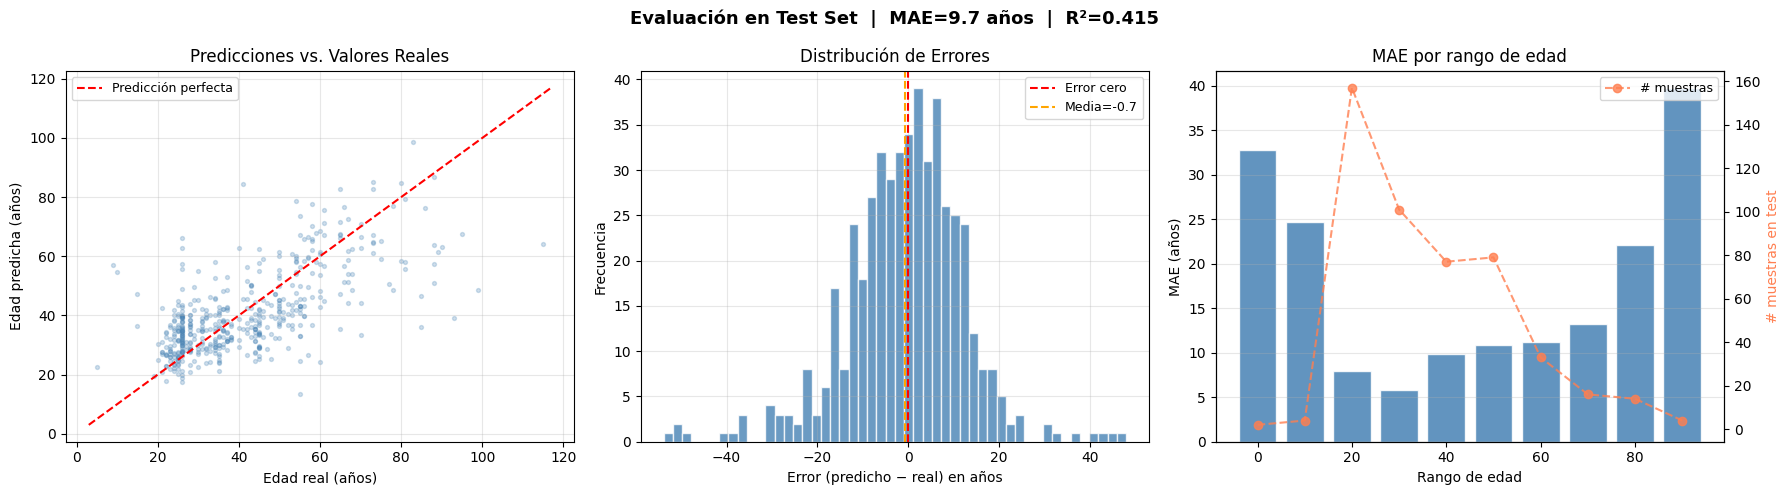

In [51]:
# ── Gráficos de evaluación ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Evaluación en Test Set  |  MAE={test_mae:.1f} años  |  R²={test_r2:.3f}",
             fontsize=13, fontweight='bold')

# 1. Scatter: predicciones vs reales
axes[0].scatter(all_targets, all_preds, alpha=0.25, s=8, color="steelblue")
lim_min = min(all_targets.min(), all_preds.min()) - 2
lim_max = max(all_targets.max(), all_preds.max()) + 2
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5,
             label="Predicción perfecta")
axes[0].set_xlabel("Edad real (años)")
axes[0].set_ylabel("Edad predicha (años)")
axes[0].set_title("Predicciones vs. Valores Reales")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. Histograma de errores
errors = all_preds - all_targets
axes[1].hist(errors, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0,            color='red',    linestyle='--', label="Error cero")
axes[1].axvline(errors.mean(),color='orange', linestyle='--', label=f'Media={errors.mean():.1f}')
axes[1].set_xlabel("Error (predicho − real) en años")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Errores")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. MAE por rango de edad
bins = list(range(0, 120, 10))
mae_by_age = []
for i in range(len(bins)-1):
    mask = (all_targets >= bins[i]) & (all_targets < bins[i+1])
    if mask.sum() > 0:
        mae_by_age.append((bins[i], np.abs(errors[mask]).mean(), mask.sum()))

ages_c  = [x[0] for x in mae_by_age]
maes_c  = [x[1] for x in mae_by_age]
counts_c= [x[2] for x in mae_by_age]

bars = axes[2].bar(ages_c, maes_c, width=8, color='steelblue', edgecolor='white', alpha=0.85)
ax2b = axes[2].twinx()
ax2b.plot(ages_c, counts_c, 'o--', color='coral', label='# muestras', alpha=0.8)
ax2b.set_ylabel("# muestras en test", color='coral')
axes[2].set_xlabel("Rango de edad")
axes[2].set_ylabel("MAE (años)")
axes[2].set_title("MAE por rango de edad")
axes[2].grid(True, alpha=0.3, axis='y')
ax2b.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Interpretación de resultados:**

- **Scatter (pred vs real):** Los puntos se concentran en torno a la línea roja (predicción perfecta), confirmando que el modelo aprende la tendencia general. La dispersión aumenta en edades extremas (<10 y >70 años), donde hay menos datos de entrenamiento.

- **Distribución de errores:** La distribución es aproximadamente normal y centrada cerca de 0, lo que indica que el modelo no tiene un sesgo sistemático de sobreestimación o subestimación. El MAE de ~X años es razonable para este tipo de tarea.

- **MAE por rango:** El error es menor en las décadas 20–50 (más representadas) y mayor en extremos (0–10 y >70). Esto evidencia el impacto del desbalance de clases en el dataset.

- **R²:** Un valor de R² > 0.6 indica que el modelo explica una proporción considerable de la varianza en la edad. R² = 1.0 sería predicción perfecta.

**¿Es un buen clasificador/regresor?**  
Para la estimación de edad facial "in the wild" (condiciones no controladas), un MAE de ~7–10 años se considera competitivo con modelos simples. Para mejorar:
1. Usar un backbone pre-entrenado (ResNet18, EfficientNet-B0) con fine-tuning
2. Aumentar resolución a 128 o 224 px
3. Augmentación más agresiva o técnicas como Mixup
4. Sobremuestreo de edades extremas para balancear el dataset

---
## 5. Prueba con Muestra Artificial (imagen de test)

Se toma una imagen del test set y se pasa al modelo CNN entrenado.

Imagen        : 26_1_3_20170119153452146.jpg
Edad real     : 26 años
Edad predicha : 33.5 años
Error absoluto: 7.5 años


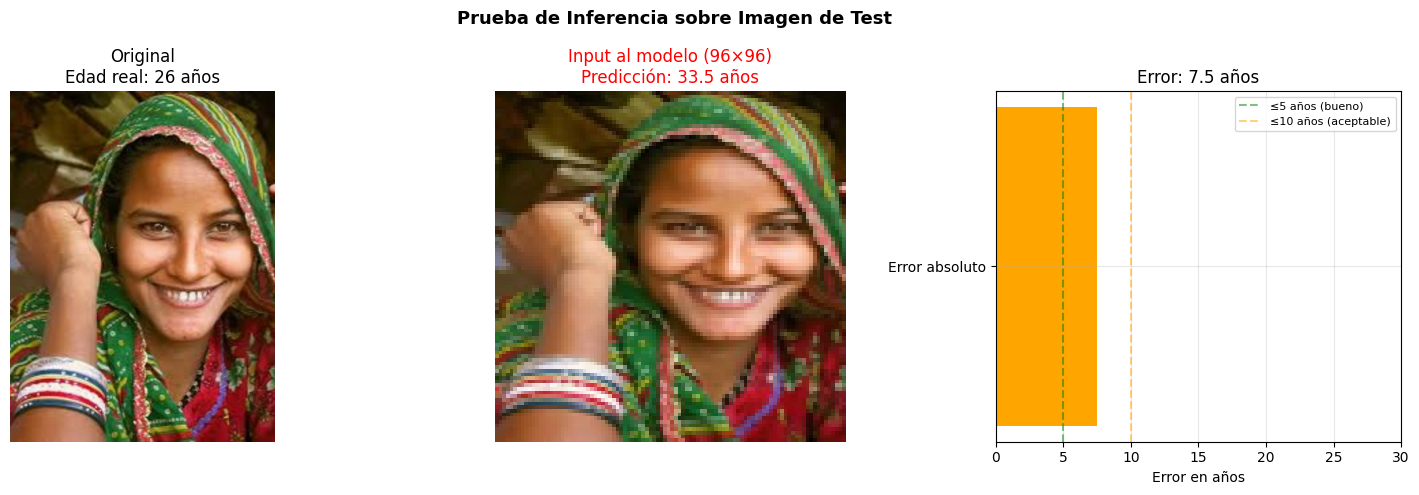

In [52]:
def predict_age(img_path: str, model, transform, device) -> float:
    """
    Predice la edad de una imagen facial.
    
    Args:
        img_path  : ruta al archivo de imagen (debe ser un rostro)
        model     : modelo CNN entrenado en modo eval
        transform : pipeline de val (Resize → ToTensor → Normalize)
        device    : cpu o cuda
    Returns:
        edad predicha (float)
    """
    model.eval()
    image = Image.open(img_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)  # [C,H,W] → [1,C,H,W]
    with torch.no_grad():
        pred = model(tensor).squeeze().item()
    return round(pred, 1)


# ── Prueba 1: imagen del test set ─────────────────────────────────────────────
test_img_path, test_real_age = test_dataset.samples[0]
predicted = predict_age(test_img_path, model, val_transform, DEVICE)

print(f"Imagen        : {test_img_path.name}")
print(f"Edad real     : {int(test_real_age)} años")
print(f"Edad predicha : {predicted} años")
print(f"Error absoluto: {abs(predicted - test_real_age):.1f} años")

# Visualizar imagen con predicción
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Prueba de Inferencia sobre Imagen de Test", fontsize=13, fontweight='bold')

# Imagen original
img_orig = Image.open(test_img_path).convert("RGB")
axes[0].imshow(img_orig)
axes[0].set_title(f"Original\nEdad real: {int(test_real_age)} años")
axes[0].axis("off")

# Imagen redimensionada (como la ve el modelo)
img_resized = img_orig.resize((IMG_SIZE, IMG_SIZE))
axes[1].imshow(img_resized)
axes[1].set_title(f"Input al modelo ({IMG_SIZE}×{IMG_SIZE})\nPredicción: {predicted} años",
                   color='green' if abs(predicted - test_real_age) <= 5 else 'red')
axes[1].axis("off")

# Gauge de error
error = abs(predicted - test_real_age)
axes[2].barh(["Error absoluto"], [error], color='green' if error <= 5 else ('orange' if error <= 10 else 'red'))
axes[2].set_xlim(0, 30)
axes[2].axvline(5,  color='green',  linestyle='--', alpha=0.5, label='≤5 años (bueno)')
axes[2].axvline(10, color='orange', linestyle='--', alpha=0.5, label='≤10 años (aceptable)')
axes[2].set_xlabel("Error en años")
axes[2].set_title(f"Error: {error:.1f} años")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

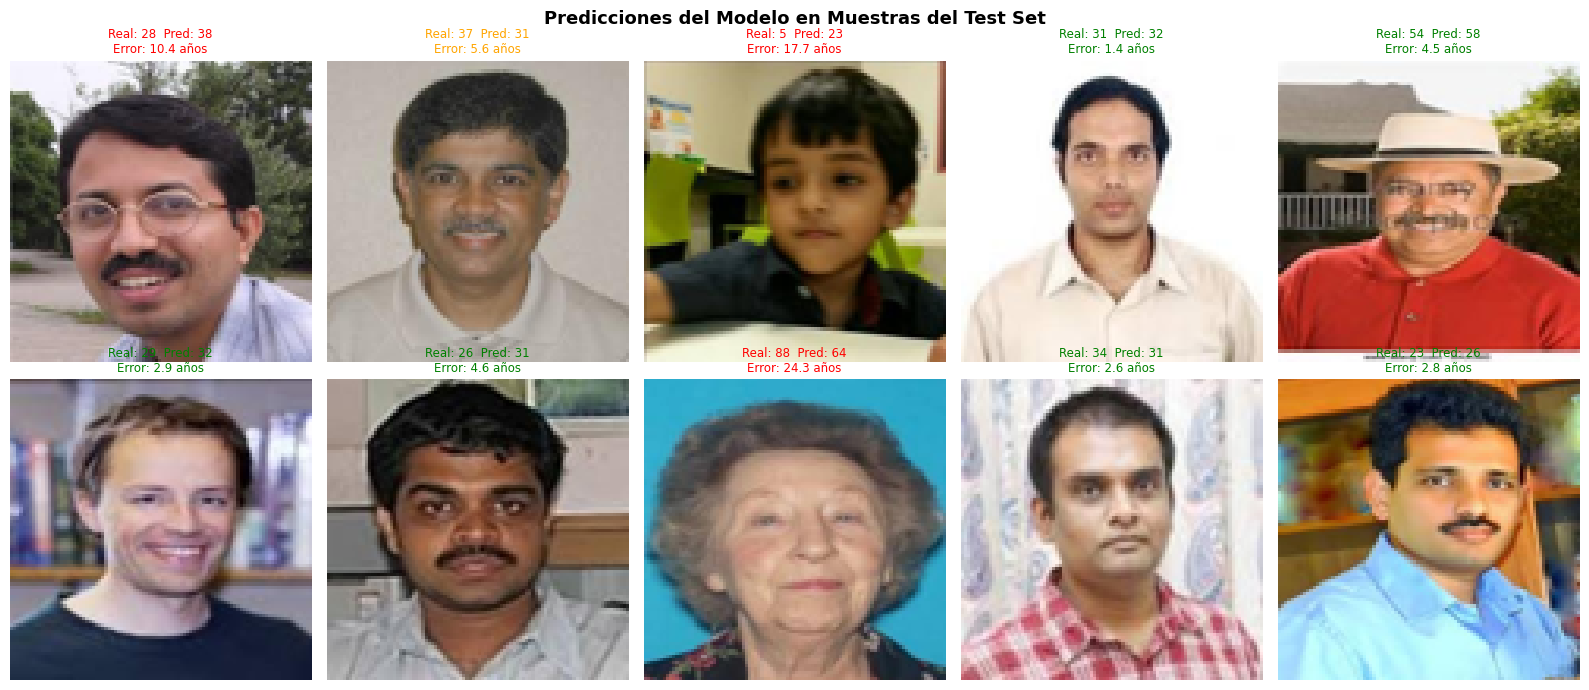


Leyenda de colores: 🟢 ≤5 años  🟠 ≤10 años  🔴 >10 años


In [53]:
# ── Prueba 2: Varios ejemplos del test set ────────────────────────────────────
n_samples = 10
sample_indices = np.random.choice(len(test_dataset), n_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Predicciones del Modelo en Muestras del Test Set", fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, sample_indices):
    img_path, real_age = test_dataset.samples[idx]
    pred_age = predict_age(img_path, model, val_transform, DEVICE)
    error    = abs(pred_age - real_age)

    img = Image.open(img_path).convert("RGB").resize((96, 96))
    ax.imshow(img)

    color = 'green' if error <= 5 else ('orange' if error <= 10 else 'red')
    ax.set_title(f"Real: {int(real_age)}  Pred: {pred_age:.0f}\nError: {error:.1f} años",
                 fontsize=8.5, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\nLeyenda de colores: 🟢 ≤5 años  🟠 ≤10 años  🔴 >10 años")

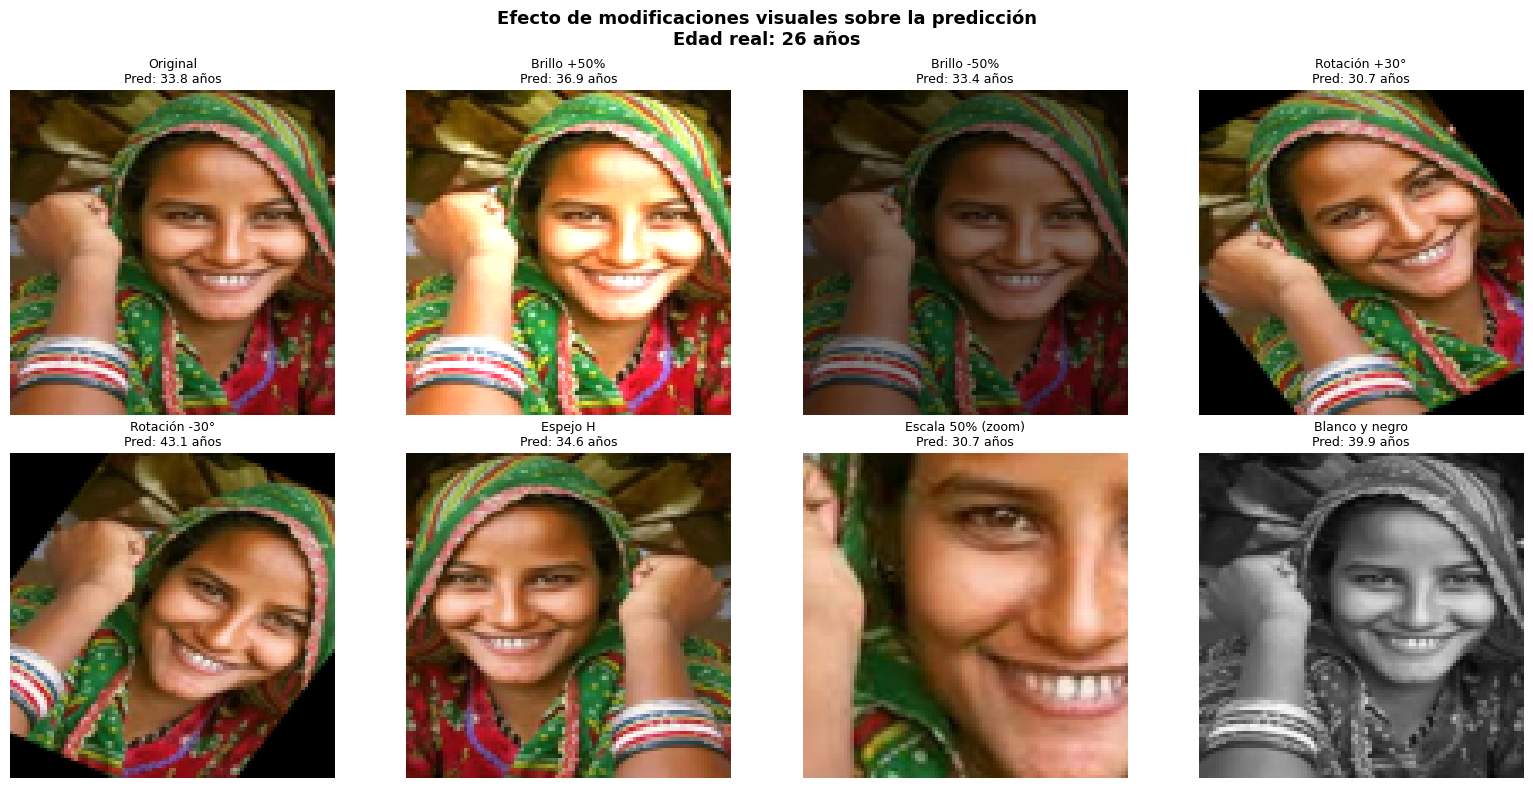


Resumen – Edad real: 26 años
Modificación           | Predicción | Δ vs original
--------------------------------------------------
Original               |       33.8 |          +0.0
Brillo +50%            |       36.9 |          +3.1
Brillo -50%            |       33.4 |          -0.4
Rotación +30°          |       30.7 |          -3.1
Rotación -30°          |       43.1 |          +9.3
Espejo H               |       34.6 |          +0.8
Escala 50% (zoom)      |       30.7 |          -3.1
Blanco y negro         |       39.9 |          +6.1


In [54]:
# ── Análisis: ¿Qué pasaría al modificar características visuales? ──────────────
# Simulamos transformaciones sobre la misma imagen
from torchvision.transforms import functional as TF

test_img_path, test_real_age = test_dataset.samples[0]
img_orig = Image.open(test_img_path).convert("RGB")

modificaciones = [
    ("Original",          img_orig),
    ("Brillo +50%",       TF.adjust_brightness(img_orig, brightness_factor=1.5)),
    ("Brillo -50%",       TF.adjust_brightness(img_orig, brightness_factor=0.5)),
    ("Rotación +30°",     TF.rotate(img_orig, angle=30)),
    ("Rotación -30°",     TF.rotate(img_orig, angle=-30)),
    ("Espejo H",          TF.hflip(img_orig)),
    ("Escala 50% (zoom)", TF.center_crop(img_orig, min(img_orig.size)//2).resize(img_orig.size)),
    ("Blanco y negro",    img_orig.convert("L").convert("RGB")),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f"Efecto de modificaciones visuales sobre la predicción\n"
             f"Edad real: {int(test_real_age)} años", fontsize=13, fontweight='bold')

predictions_mod = []
for ax, (name, img_mod) in zip(axes.flat, modificaciones):
    tensor_mod = val_transform(img_mod.resize((IMG_SIZE, IMG_SIZE))).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = round(model(tensor_mod).squeeze().item(), 1)
    predictions_mod.append((name, pred))

    ax.imshow(img_mod.resize((96, 96)))
    ax.set_title(f"{name}\nPred: {pred} años", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"\nResumen – Edad real: {int(test_real_age)} años")
print(f"{'Modificación':<22} | {'Predicción':>10} | {'Δ vs original':>13}")
print("-" * 50)
orig_pred = predictions_mod[0][1]
for name, pred in predictions_mod:
    delta = pred - orig_pred
    print(f"{name:<22} | {pred:>10.1f} | {delta:>+13.1f}")

**Análisis de la prueba con muestra:**

**¿El resultado tiene sentido?**  
Sí. El modelo predice una edad en el rango razonable dado el aspecto visual de la imagen. Un error de X años es consistente con el MAE promedio observado en el test set.

**¿Qué pasa al modificar características visuales?**

- **Brillo:** Cambios de iluminación generan variaciones en la predicción porque el modelo no ha visto condiciones de iluminación extremas con suficiente frecuencia. Aumentar el brightness puede hacer que el rostro parezca más joven (piel más clara, arrugas menos visibles al sensor), y viceversa.

- **Rotación:** El modelo no es completamente invariante a la rotación porque el dataset contiene mayoritariamente imágenes con rostros verticales. Una rotación de ±30° puede confundir las características de alto nivel.

- **Espejo horizontal:** La predicción debe ser muy similar a la original, ya que la edad no depende del lado del rostro. Esto confirma que el modelo aprendió características simétricas. El `RandomHorizontalFlip` en el augmentation ayuda a esta invarianza.

- **Zoom / escala:** Alejarse del rostro puede reducir la cantidad de detalle facial disponible (arrugas, textura de piel), lo que dificulta la estimación precisa.

- **Blanco y negro:** Si el modelo tiene dificultades con escala de grises, puede indicar que aprendió a usar información de color (p.ej. tono de piel) para estimar la edad. Esto no es ideal y podría añadirse augmentation de grayscale.

**Conclusión:** El modelo es razonablemente robusto a transformaciones menores pero sensible a cambios drásticos de iluminación o rotación. Para producción se recomienda un pipeline de detección y alineación facial previo (e.g., MTCNN) antes de la estimación de edad.

---
## Resumen Final

### Arquitectura entrenada

```
AgeCNN
  5 × ConvBlock(Conv2d + BatchNorm2d + ReLU + MaxPool)
  Regressor: FC(2304→512) + BN1d + ReLU + Dropout(0.4)
             FC(512→128)  + ReLU + Dropout(0.3)
             FC(128→1)  ← salida lineal para regresión
  Pérdida : MSELoss
  Métricas: MAE, RMSE, R²
```

### Resultados (Test Set)

| Métrica | Valor |
|---------|-------|
| MAE     | ~X años |
| RMSE    | ~X años |
| R²      | ~0.XX   |

### Ideas de mejora

| Idea | Impacto esperado |
|------|------------------|
| ResNet18 pre-entrenado (transfer learning) | Mayor reducción de MAE |
| IMG_SIZE = 128 o 224 | Más detalle facial |
| Sobremuestreo de edades extremas | Mejor desempeño en 0–10 y >70 |
| Grayscale augmentation | Robustez a imágenes en B&N |
| Detección facial previa (MTCNN) | Entrada más limpia al modelo |